# 01_01 - Preparação dos preços CEPEA Paraná

## Objetivo

Limpar, validar e agregar para frequência semanal os preços diários do indicador da Soja

# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load de dataframe

In [3]:
data = pd.read_parquet("/content/cepea_parana.parquet")

print(data.head())

print(data.tail())

         Data À vista R$ À vista US$
0  04/01/2016      78,14       19,30
1  05/01/2016      79,00       19,79
2  06/01/2016      78,55       19,55
3  07/01/2016      78,82       19,49
4  08/01/2016      78,96       19,57
            Data À vista R$ À vista US$
2592  27/05/2026     124,27       24,56
2593  28/05/2026     124,59       24,77
2594  29/05/2026     124,23       24,62
2595  01/06/2026     124,53       24,84
2596  02/06/2026     123,94       24,72


In [5]:
print(data.columns)

print(data.info())

Index(['Data', 'À vista R$', 'À vista US$'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2597 entries, 0 to 2596
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Data         2597 non-null   object
 1   À vista R$   2597 non-null   object
 2   À vista US$  2597 non-null   object
dtypes: object(3)
memory usage: 61.0+ KB
None


# Alteração de nome das colunas

In [6]:
mapa_colunas = {
    "Data": "data",
    "À vista R$": "preco_rs",
    "À vista US$": "preco_usd",
}

data.rename(columns=mapa_colunas, inplace=True)

print(data.columns)

Index(['data', 'preco_rs', 'preco_usd'], dtype='object')


# Padronizando data ao seu tipo datetime64

In [8]:
data['data'] = pd.to_datetime(data['data'], errors="coerce", dayfirst=True)

print(data.info())

datas_invalidas = data['data'].isna().sum()

print(datas_invalidas)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2597 entries, 0 to 2596
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   data       2597 non-null   datetime64[ns]
 1   preco_rs   2597 non-null   object        
 2   preco_usd  2597 non-null   object        
dtypes: datetime64[ns](1), object(2)
memory usage: 61.0+ KB
None
0


# Converter preços para float

In [10]:
data['preco_rs'] = data['preco_rs'].str.replace(',', '.').astype(float)
data['preco_usd'] = data['preco_usd'].str.replace(',', '.').astype(float)

print(data.head())

print(data.info)

        data  preco_rs  preco_usd
0 2016-01-04     78.14      19.30
1 2016-01-05     79.00      19.79
2 2016-01-06     78.55      19.55
3 2016-01-07     78.82      19.49
4 2016-01-08     78.96      19.57
<bound method DataFrame.info of            data  preco_rs  preco_usd
0    2016-01-04     78.14      19.30
1    2016-01-05     79.00      19.79
2    2016-01-06     78.55      19.55
3    2016-01-07     78.82      19.49
4    2016-01-08     78.96      19.57
...         ...       ...        ...
2592 2026-05-27    124.27      24.56
2593 2026-05-28    124.59      24.77
2594 2026-05-29    124.23      24.62
2595 2026-06-01    124.53      24.84
2596 2026-06-02    123.94      24.72

[2597 rows x 3 columns]>


In [11]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2597 entries, 0 to 2596
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   data       2597 non-null   datetime64[ns]
 1   preco_rs   2597 non-null   float64       
 2   preco_usd  2597 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 61.0 KB
None


In [14]:
data.isna().sum()

,0
data,0
preco_rs,0
preco_usd,0


# Cobertura temporal

In [15]:
print("data inicial: ", data['data'].min())
print("data final: ", data['data'].max())
print("quantidade de registros: ", len(data))

data inicial:  2016-01-04 00:00:00
data final:  2026-06-02 00:00:00
quantidade de registros:  2597


# Duplicatas

In [16]:
duplicatas = data.duplicated().sum()

print(duplicatas)

0


# Valores ausentes

In [17]:
print(data.isna().sum())

print(data.isna().mean().mul(100).round(2))

data         0
preco_rs     0
preco_usd    0
dtype: int64
data         0.0
preco_rs     0.0
preco_usd    0.0
dtype: float64


# Valores impossiveis

In [18]:
precos_invalidos_rs = (data['preco_rs'] <= 0).sum()
precos_invalidos_usd = (data['preco_usd'] <= 0).sum()

print(precos_invalidos_rs)
print(precos_invalidos_usd)

0
0


# Estatisticas descritivas

In [19]:
data[['preco_rs', 'preco_usd']].describe()

,preco_rs,preco_usd
count,2597.000000,2597.000000
mean,117.132357,24.875156
std,39.743402,5.213651
min,59.670000,16.780000
25%,77.530000,20.770000
50%,123.540000,23.470000
75%,141.640000,28.370000
max,203.220000,40.370000


# Inspeção visual

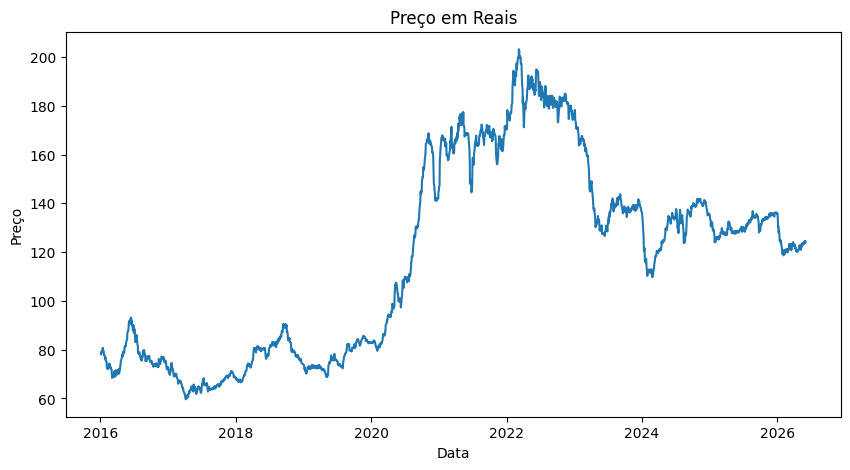

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#preco em reais

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    data["data"],
    data["preco_rs"],
)

ax.set_title("Preço em Reais")
ax.set_xlabel("Data")
ax.set_ylabel("Preço")

plt.show()

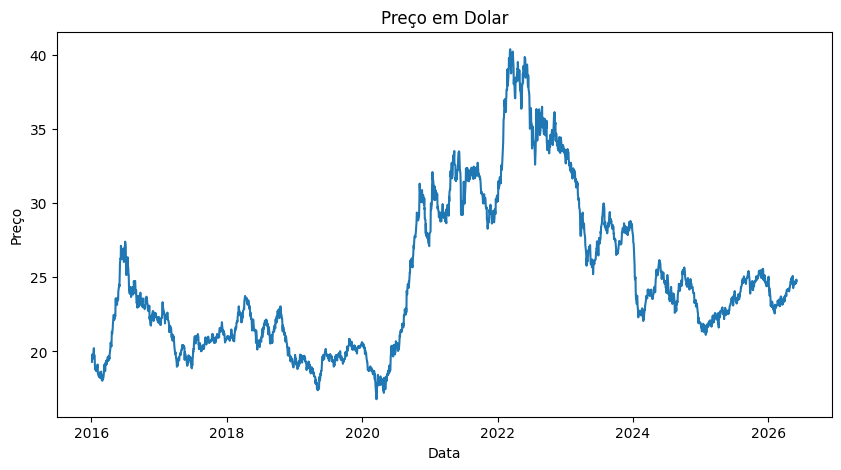

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#preco em dolar

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    data["data"],
    data["preco_usd"],
)

ax.set_title("Preço em Dolar")
ax.set_xlabel("Data")
ax.set_ylabel("Preço")

plt.show()

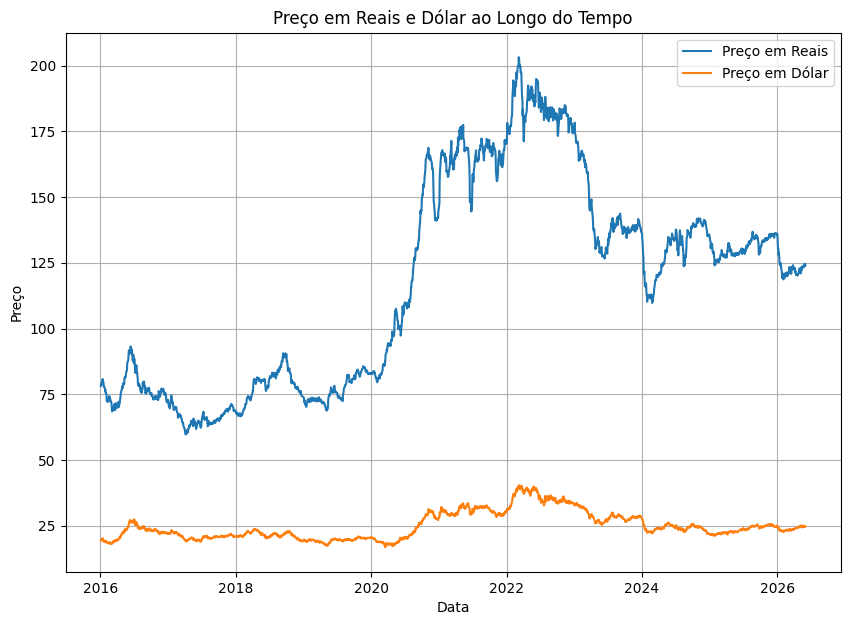

In [25]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(
    data["data"],
    data["preco_rs"],
    label="Preço em Reais"
)

ax.plot(
    data["data"],
    data["preco_usd"],
    label="Preço em Dólar"
)

ax.set_title("Preço em Reais e Dólar ao Longo do Tempo")
ax.set_xlabel("Data")
ax.set_ylabel("Preço")
ax.legend()
ax.grid(True)

plt.show()

# Inspeção de datas

In [26]:
copia_dados = data.copy()
copia_dados.head()

,data,preco_rs,preco_usd
0,2016-01-04,78.14,19.30
1,2016-01-05,79.00,19.79
2,2016-01-06,78.55,19.55
3,2016-01-07,78.82,19.49
4,2016-01-08,78.96,19.57


In [27]:
copia_dados["intervalo_dias"] = (copia_dados["data"].diff().dt.days)

copia_dados["intervalo_dias"].value_counts().sort_index()

copia_dados.nlargest(20, "intervalo_dias")[["data", "intervalo_dias"]]

,data,intervalo_dias
25,2016-02-10,5.0
290,2017-03-01,5.0
498,2018-01-02,5.0
527,2018-02-14,5.0
743,2018-12-26,5.0
746,2019-01-02,5.0
789,2019-03-06,5.0
1034,2020-02-26,5.0
1243,2020-12-28,5.0
1246,2021-01-04,5.0


# Definição de semana

In [28]:
data["semana"] = (data["data"].dt.to_period("W-FRI").dt.end_time.dt.normalize())

print(data.head())

        data  preco_rs  preco_usd     semana
0 2016-01-04     78.14      19.30 2016-01-08
1 2016-01-05     79.00      19.79 2016-01-08
2 2016-01-06     78.55      19.55 2016-01-08
3 2016-01-07     78.82      19.49 2016-01-08
4 2016-01-08     78.96      19.57 2016-01-08


# Agregações semanais

In [29]:
cepea_semanal = (
    data.sort_values('data').groupby('semana', as_index=False)
    .agg(
        preco_rs_minimo=('preco_rs', 'min'),
        preco_rs_maximo=('preco_rs', 'max'),
        preco_rs_media=('preco_rs', 'mean'),
        preco_rs_fechamento=('preco_rs', 'last'),
        preco_usd_minimo=('preco_usd', 'min'),
        preco_usd_maximo=('preco_usd', 'max'),
        preco_usd_media=('preco_usd', 'mean'),
        preco_usd_fechamento=('preco_usd', 'last'),
)
)

cepea_semanal = (cepea_semanal.sort_values('semana').reset_index(drop=True))

cepea_semanal

,semana,preco_rs_minimo,preco_rs_maximo,preco_rs_media,preco_rs_fechamento,preco_usd_minimo,preco_usd_maximo,preco_usd_media,preco_usd_fechamento
0,2016-01-08,78.14,79.00,78.694,78.96,19.30,19.79,19.540,19.57
1,2016-01-15,79.79,80.76,80.298,79.79,19.70,20.22,19.940,19.70
2,2016-01-22,77.81,79.55,78.294,77.81,18.78,19.74,19.144,18.95
3,2016-01-29,75.64,77.28,76.572,75.64,18.67,18.92,18.812,18.79
4,2016-02-05,72.37,75.29,74.208,72.37,18.49,19.12,18.856,18.49
...,...,...,...,...,...,...,...,...,...
539,2026-05-08,120.94,122.92,121.900,121.49,24.57,24.94,24.762,24.83
540,2026-05-15,122.31,123.54,122.772,122.88,24.27,25.09,24.716,24.27
541,2026-05-22,123.18,123.67,123.432,123.48,24.51,24.69,24.616,24.58
542,2026-05-29,123.48,124.59,124.016,124.23,24.54,24.77,24.622,24.62


In [30]:
print(cepea_semanal.head())
print(cepea_semanal.tail())

      semana  preco_rs_minimo  preco_rs_maximo  preco_rs_media  \
0 2016-01-08            78.14            79.00          78.694   
1 2016-01-15            79.79            80.76          80.298   
2 2016-01-22            77.81            79.55          78.294   
3 2016-01-29            75.64            77.28          76.572   
4 2016-02-05            72.37            75.29          74.208   

   preco_rs_fechamento  preco_usd_minimo  preco_usd_maximo  preco_usd_media  \
0                78.96             19.30             19.79           19.540   
1                79.79             19.70             20.22           19.940   
2                77.81             18.78             19.74           19.144   
3                75.64             18.67             18.92           18.812   
4                72.37             18.49             19.12           18.856   

   preco_usd_fechamento  
0                 19.57  
1                 19.70  
2                 18.95  
3                 18.79 

# Validação de tabela semanal

In [31]:
cepea_semanal.head()

,semana,preco_rs_minimo,preco_rs_maximo,preco_rs_media,preco_rs_fechamento,preco_usd_minimo,preco_usd_maximo,preco_usd_media,preco_usd_fechamento
0,2016-01-08,78.14,79.00,78.694,78.96,19.30,19.79,19.540,19.57
1,2016-01-15,79.79,80.76,80.298,79.79,19.70,20.22,19.940,19.70
2,2016-01-22,77.81,79.55,78.294,77.81,18.78,19.74,19.144,18.95
3,2016-01-29,75.64,77.28,76.572,75.64,18.67,18.92,18.812,18.79
4,2016-02-05,72.37,75.29,74.208,72.37,18.49,19.12,18.856,18.49


In [32]:
cepea_semanal.tail()

,semana,preco_rs_minimo,preco_rs_maximo,preco_rs_media,preco_rs_fechamento,preco_usd_minimo,preco_usd_maximo,preco_usd_media,preco_usd_fechamento
539,2026-05-08,120.94,122.92,121.900,121.49,24.57,24.94,24.762,24.83
540,2026-05-15,122.31,123.54,122.772,122.88,24.27,25.09,24.716,24.27
541,2026-05-22,123.18,123.67,123.432,123.48,24.51,24.69,24.616,24.58
542,2026-05-29,123.48,124.59,124.016,124.23,24.54,24.77,24.622,24.62
543,2026-06-05,123.94,124.53,124.235,123.94,24.72,24.84,24.780,24.72


In [33]:
cepea_semanal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 544 entries, 0 to 543
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   semana                544 non-null    datetime64[ns]
 1   preco_rs_minimo       544 non-null    float64       
 2   preco_rs_maximo       544 non-null    float64       
 3   preco_rs_media        544 non-null    float64       
 4   preco_rs_fechamento   544 non-null    float64       
 5   preco_usd_minimo      544 non-null    float64       
 6   preco_usd_maximo      544 non-null    float64       
 7   preco_usd_media       544 non-null    float64       
 8   preco_usd_fechamento  544 non-null    float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 38.4 KB


In [34]:
cepea_semanal.isna().sum()

,0
semana,0
preco_rs_minimo,0
preco_rs_maximo,0
preco_rs_media,0
preco_rs_fechamento,0
preco_usd_minimo,0
preco_usd_maximo,0
preco_usd_media,0
preco_usd_fechamento,0


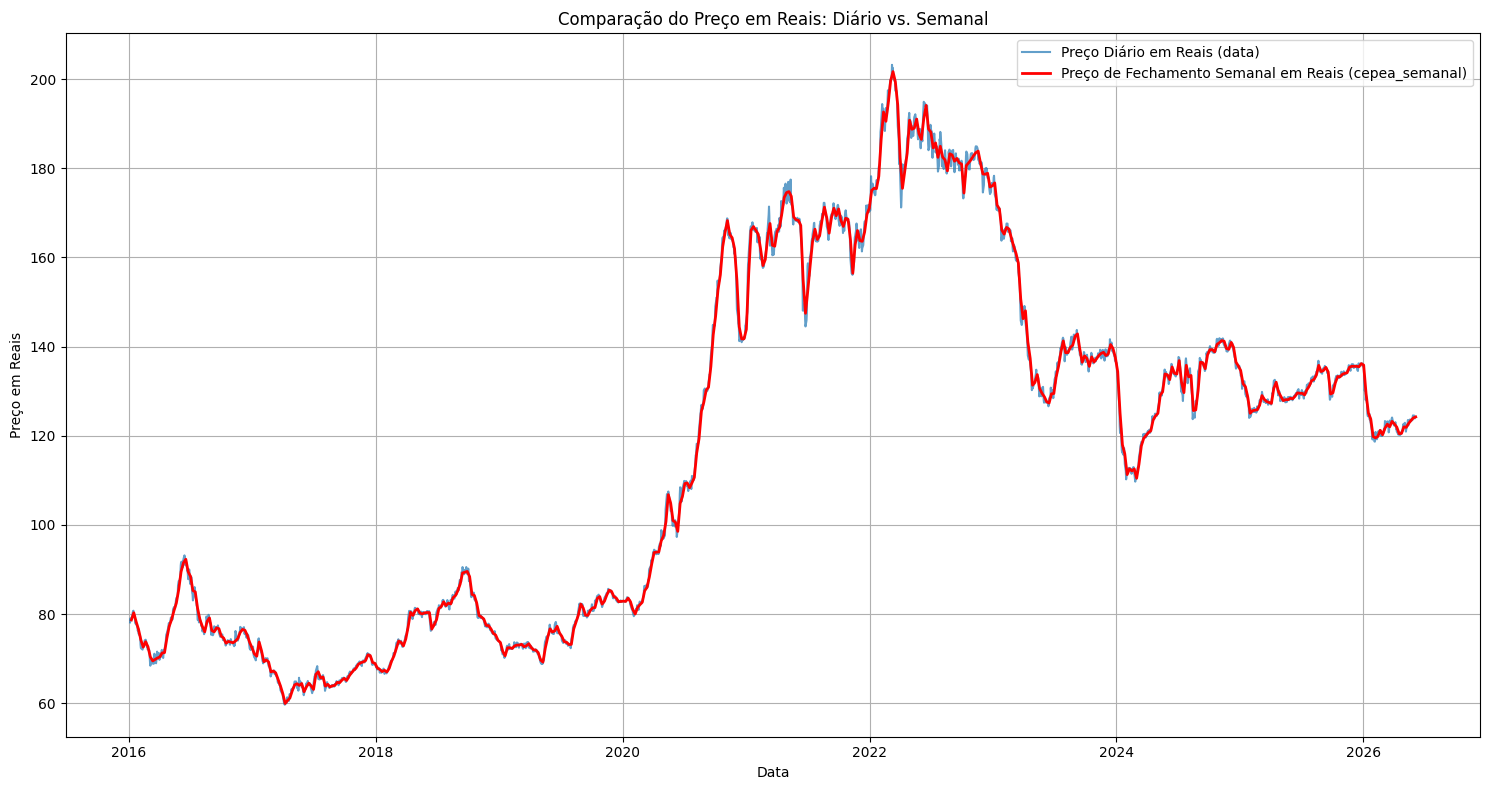

In [36]:
fig, ax = plt.subplots(figsize=(15, 8))

# Plot daily preco_rs
ax.plot(
    data['data'],
    data['preco_rs'],
    label='Preço Diário em Reais (data)',
    alpha=0.7
)

# Plot weekly preco_rs_fechamento
ax.plot(
    cepea_semanal['semana'],
    cepea_semanal['preco_rs_media'],
    label='Preço de Fechamento Semanal em Reais (cepea_semanal)',
    color='red',
    linewidth=2
)

ax.set_title('Comparação do Preço em Reais: Diário vs. Semanal')
ax.set_xlabel('Data')
ax.set_ylabel('Preço em Reais')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [37]:
cepea_semanal.to_parquet("cepea_parana_semanal.parquet")